# NHS A&E February 2026 SQL Portfolio Project

## Project Goal
This project analyses NHS A&E performance data for February 2026 using:

- Python
- Pandas
- SQLite
- SQL
- Matplotlib / Seaborn

## Objectives
- Clean and prepare the dataset
- Load it into SQLite
- Answer business questions with SQL
- Create portfolio-ready insights and visuals

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
# Set file paths
csv_path = "../data/February-2026-CSV-Dl8t54.csv"
db_path = "../nhs_ae_feb_2026.db"
table_name = "nhs_ae_waiting_times"

In [3]:
df = pd.read_csv(csv_path)
df.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,Attendances over 4hrs Type 1,Attendances over 4hrs Type 2,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-FEBRUARY-2026,Y02676,NHS ENGLAND SOUTH EAST,BRIGHTON STATION HEALTH CENTRE,0,0,1736,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,MSitAE-FEBRUARY-2026,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,537,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,MSitAE-FEBRUARY-2026,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,MSitAE-FEBRUARY-2026,C82038,NHS ENGLAND MIDLANDS,LATHAM HOUSE MEDICAL PRACTICE,0,0,295,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,MSitAE-FEBRUARY-2026,C83023,NHS ENGLAND MIDLANDS,SLEAFORD MEDICAL GROUP,0,0,506,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [4]:
df.shape

(198, 22)

In [5]:
df.columns.tolist()

['Period',
 'Org Code',
 'Parent Org',
 'Org name',
 'A&E attendances Type 1',
 'A&E attendances Type 2',
 'A&E attendances Other A&E Department',
 'A&E attendances Booked Appointments Type 1',
 'A&E attendances Booked Appointments Type 2',
 'A&E attendances Booked Appointments Other Department',
 'Attendances over 4hrs Type 1',
 'Attendances over 4hrs Type 2',
 'Attendances over 4hrs Other Department',
 'Attendances over 4hrs Booked Appointments Type 1',
 'Attendances over 4hrs Booked Appointments Type 2',
 'Attendances over 4hrs Booked Appointments Other Department',
 'Patients who have waited 4-12 hs from DTA to admission',
 'Patients who have waited 12+ hrs from DTA to admission',
 'Emergency admissions via A&E - Type 1',
 'Emergency admissions via A&E - Type 2',
 'Emergency admissions via A&E - Other A&E department',
 'Other emergency admissions']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 22 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   Period                                                      198 non-null    object
 1   Org Code                                                    198 non-null    object
 2   Parent Org                                                  198 non-null    object
 3   Org name                                                    198 non-null    object
 4   A&E attendances Type 1                                      198 non-null    int64 
 5   A&E attendances Type 2                                      198 non-null    int64 
 6   A&E attendances Other A&E Department                        198 non-null    int64 
 7   A&E attendances Booked Appointments Type 1                  198 non-null    int64 
 8   A&E attend

In [7]:
df.isnull().sum()

Period                                                        0
Org Code                                                      0
Parent Org                                                    0
Org name                                                      0
A&E attendances Type 1                                        0
A&E attendances Type 2                                        0
A&E attendances Other A&E Department                          0
A&E attendances Booked Appointments Type 1                    0
A&E attendances Booked Appointments Type 2                    0
A&E attendances Booked Appointments Other Department          0
Attendances over 4hrs Type 1                                  0
Attendances over 4hrs Type 2                                  0
Attendances over 4hrs Other Department                        0
Attendances over 4hrs Booked Appointments Type 1              0
Attendances over 4hrs Booked Appointments Type 2              0
Attendances over 4hrs Booked Appointment

In [8]:
raw_df = df.copy()

In [9]:
# Clean column names
df["Period"] = pd.to_datetime(df["Period"].str.replace("MSitAE-", ""), format="%B-%Y")

def clean_column_name(col):
    col = col.strip().lower()
    col = col.replace("&", "and")
    col = col.replace("+", "plus")
    col = col.replace("-", "_")
    col = col.replace("/", "_")
    col = col.replace(" ", "_")
    col = col.replace(".", "")
    return col

df.columns = [clean_column_name(col) for col in df.columns]
df.columns.tolist()

['period',
 'org_code',
 'parent_org',
 'org_name',
 'aande_attendances_type_1',
 'aande_attendances_type_2',
 'aande_attendances_other_aande_department',
 'aande_attendances_booked_appointments_type_1',
 'aande_attendances_booked_appointments_type_2',
 'aande_attendances_booked_appointments_other_department',
 'attendances_over_4hrs_type_1',
 'attendances_over_4hrs_type_2',
 'attendances_over_4hrs_other_department',
 'attendances_over_4hrs_booked_appointments_type_1',
 'attendances_over_4hrs_booked_appointments_type_2',
 'attendances_over_4hrs_booked_appointments_other_department',
 'patients_who_have_waited_4_12_hs_from_dta_to_admission',
 'patients_who_have_waited_12plus_hrs_from_dta_to_admission',
 'emergency_admissions_via_aande___type_1',
 'emergency_admissions_via_aande___type_2',
 'emergency_admissions_via_aande___other_aande_department',
 'other_emergency_admissions']

In [10]:
# Preview cleaned Data
df.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions
0,2026-02-01,Y02676,NHS ENGLAND SOUTH EAST,BRIGHTON STATION HEALTH CENTRE,0,0,1736,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2026-02-01,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,537,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2026-02-01,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2026-02-01,C82038,NHS ENGLAND MIDLANDS,LATHAM HOUSE MEDICAL PRACTICE,0,0,295,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2026-02-01,C83023,NHS ENGLAND MIDLANDS,SLEAFORD MEDICAL GROUP,0,0,506,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [11]:
#Check numeric columns
df.dtypes

period                                                        datetime64[ns]
org_code                                                              object
parent_org                                                            object
org_name                                                              object
aande_attendances_type_1                                               int64
aande_attendances_type_2                                               int64
aande_attendances_other_aande_department                               int64
aande_attendances_booked_appointments_type_1                           int64
aande_attendances_booked_appointments_type_2                           int64
aande_attendances_booked_appointments_other_department                 int64
attendances_over_4hrs_type_1                                           int64
attendances_over_4hrs_type_2                                           int64
attendances_over_4hrs_other_department                                 int64

In [12]:
# Convert attendance and admission columns to numeric
numeric_cols = [
    "aande_attendances_type_1",
    "aande_attendances_type_2",
    "aande_attendances_other_aande_department",
    "aande_attendances_booked_appointments_type_1",
    "aande_attendances_booked_appointments_type_2",
    "aande_attendances_booked_appointments_other_department",
    "attendances_over_4hrs_type_1",
    "attendances_over_4hrs_type_2",
    "attendances_over_4hrs_other_department",
    "attendances_over_4hrs_booked_appointments_type_1",
    "attendances_over_4hrs_booked_appointments_type_2",
    "attendances_over_4hrs_booked_appointments_other_department",
    "patients_who_have_waited_4_12_hs_from_dta_to_admission",
    "patients_who_have_waited_12plus_hrs_from_dta_to_admission",
    "emergency_admissions_via_aande___type_1",
    "emergency_admissions_via_aande___type_2",
    "emergency_admissions_via_aande___other_aande_department",
    "other_emergency_admissions"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [13]:
df[numeric_cols] = df[numeric_cols].fillna(0)

# Function for feature engineering

In [14]:
def add_derived_metrics(dataframe):
    df = dataframe.copy()

    df["total_attendances"] = (
        df["aande_attendances_type_1"]
        + df["aande_attendances_type_2"]
        + df["aande_attendances_other_aande_department"]
    )

    df["total_booked_attendances"] = (
        df["aande_attendances_booked_appointments_type_1"]
        + df["aande_attendances_booked_appointments_type_2"]
        + df["aande_attendances_booked_appointments_other_department"]
    )

    df["total_over_4hrs"] = (
        df["attendances_over_4hrs_type_1"]
        + df["attendances_over_4hrs_type_2"]
        + df["attendances_over_4hrs_other_department"]
    )

    df["total_booked_over_4hrs"] = (
        df["attendances_over_4hrs_booked_appointments_type_1"]
        + df["attendances_over_4hrs_booked_appointments_type_2"]
        + df["attendances_over_4hrs_booked_appointments_other_department"]
    )

    df["total_dta_waits"] = (
        df["patients_who_have_waited_4_12_hs_from_dta_to_admission"]
        + df["patients_who_have_waited_12plus_hrs_from_dta_to_admission"]
    )

    df["total_emergency_admissions"] = (
        df["emergency_admissions_via_aande___type_1"]
        + df["emergency_admissions_via_aande___type_2"]
        + df["emergency_admissions_via_aande___other_aande_department"]
        + df["other_emergency_admissions"]
    )

    df["over_4hr_rate"] = np.where(
        df["total_attendances"] > 0,
        df["total_over_4hrs"] / df["total_attendances"],
        0
    )

    df["booked_over_4hr_rate"] = np.where(
        df["total_booked_attendances"] > 0,
        df["total_booked_over_4hrs"] / df["total_booked_attendances"],
        0
    )

    df["admission_rate"] = np.where(
        df["total_attendances"] > 0,
        df["total_emergency_admissions"] / df["total_attendances"],
        0
    )

    return df

In [15]:
df = add_derived_metrics(df)
df.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate
0,2026-02-01,Y02676,NHS ENGLAND SOUTH EAST,BRIGHTON STATION HEALTH CENTRE,0,0,1736,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1736,0,0,0,0,0,0.0,0.0,0.000000
1,2026-02-01,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,537,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,537,0,0,0,0,0,0.0,0.0,0.000000
2,2026-02-01,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,360,0,0,0,0,0,0.0,0.0,0.000000
3,2026-02-01,C82038,NHS ENGLAND MIDLANDS,LATHAM HOUSE MEDICAL PRACTICE,0,0,295,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,295,0,0,0,0,0,0.0,0.0,0.000000
4,2026-02-01,C83023,NHS ENGLAND MIDLANDS,SLEAFORD MEDICAL GROUP,0,0,506,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,506,0,0,0,0,1,0.0,0.0,0.001976


In [16]:
# Summary Statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
period,198,2026-02-01 00:00:00,2026-02-01 00:00:00,2026-02-01 00:00:00,2026-02-01 00:00:00,2026-02-01 00:00:00,2026-02-01 00:00:00,NaN
aande_attendances_type_1,198.0,12846.767677,0.0,0.0,6432.0,10321.25,1271830.0,90157.755437
aande_attendances_type_2,198.0,482.383838,0.0,0.0,0.0,0.0,47756.0,3445.66485
aande_attendances_other_aande_department,198.0,7312.989899,0.0,885.5,2703.5,5777.0,723986.0,51311.316993
aande_attendances_booked_appointments_type_1,198.0,264.393939,0.0,0.0,0.0,13.75,26175.0,1892.449847
aande_attendances_booked_appointments_type_2,198.0,4.818182,0.0,0.0,0.0,0.0,477.0,46.351529
aande_attendances_booked_appointments_other_department,198.0,477.030303,0.0,0.0,0.0,142.75,47226.0,3405.43756
attendances_over_4hrs_type_1,198.0,5252.363636,0.0,0.0,2510.5,4334.5,519984.0,36865.864949
attendances_over_4hrs_type_2,198.0,19.333333,0.0,0.0,0.0,0.0,1914.0,141.333964
attendances_over_4hrs_other_department,198.0,199.363636,0.0,0.0,19.0,139.5,19737.0,1406.532049


In [17]:
# Unique Organisations
df["org_name"].unique()

array(['BRIGHTON STATION HEALTH CENTRE', 'TETBURY HOSPITAL TRUST LTD',
       'WORKINGTON HEALTH LIMITED', 'LATHAM HOUSE MEDICAL PRACTICE',
       'SLEAFORD MEDICAL GROUP', 'HERNE BAY HEALTH CARE LTD',
       'FIRST COMMUNITY HEALTH AND CARE CIC',
       'SKELMERSDALE WALK IN CENTRE', 'ASHFORD WALK-IN-CENTRE',
       'WOKING WALK IN CENTRE',
       'TORBAY AND SOUTH DEVON NHS FOUNDATION TRUST',
       'LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDATION TRUST',
       'DORSET HEALTHCARE UNIVERSITY NHS FOUNDATION TRUST',
       'JAMES PAGET UNIVERSITY HOSPITALS NHS FOUNDATION TRUST',
       'CORNWALL PARTNERSHIP NHS FOUNDATION TRUST',
       'UNIVERSITY HOSPITALS OF MORECAMBE BAY NHS FOUNDATION TRUST',
       'HAMPSHIRE AND ISLE OF WIGHT HEALTHCARE NHS FOUNDATION TRUST',
       'SOUTH WEST YORKSHIRE PARTNERSHIP NHS FOUNDATION TRUST',
       'SOUTH WESTERN AMBULANCE SERVICE NHS FOUNDATION TRUST',
       'KENT COMMUNITY HEALTH NHS FOUNDATION TRUST',
       'MIRIAM MINOR EMERGENCY', 'SOUTH B

In [18]:
# Period values
df["period"].unique()

<DatetimeArray>
['2026-02-01 00:00:00']
Length: 1, dtype: datetime64[ns]

In [19]:
# Total row
df[df["org_name"].str.contains("TOTAL", case=False, na=False)]

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate
197,2026-02-01,TOTAL,TOTAL,TOTAL,1271830,47756,723986,26175,477,47226,519984,1914,19737,7252,35,444,77589,54649,355598,1281,5051,131085,2043572,73878,541635,7731,132238,493015,0.265043,0.104645,0.241252


In [20]:
# Save cleaned data to SQLite database
conn = sqlite3.connect(db_path)
df.to_sql(table_name, conn, if_exists="replace", index=False)
print(f"Saved to {db_path} in table: {table_name}")

Saved to ../nhs_ae_feb_2026.db in table: nhs_ae_waiting_times


In [21]:
# Test the connection with a simple SQL query
query = f"SELECT COUNT(*) AS row_count FROM {table_name}"
pd.read_sql_query(query, conn)

,row_count
0,198


In [22]:
# Show all columns in SQL table
query = f"PRAGMA table_info({table_name})"
pd.read_sql_query(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,period,TIMESTAMP,0,None,0
1,1,org_code,TEXT,0,None,0
2,2,parent_org,TEXT,0,None,0
3,3,org_name,TEXT,0,None,0
4,4,aande_attendances_type_1,INTEGER,0,None,0
5,5,aande_attendances_type_2,INTEGER,0,None,0
6,6,aande_attendances_other_aande_department,INTEGER,0,None,0
7,7,aande_attendances_booked_appointments_type_1,INTEGER,0,None,0
8,8,aande_attendances_booked_appointments_type_2,INTEGER,0,None,0
9,9,aande_attendances_booked_appointments_other_de...,INTEGER,0,None,0


In [23]:
# SQL Query 1: First 10 rows
query = f"""
SELECT *
FROM {table_name}
LIMIT 10"""
pd.read_sql_query(query, conn)

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate
0,2026-02-01 00:00:00,Y02676,NHS ENGLAND SOUTH EAST,BRIGHTON STATION HEALTH CENTRE,0,0,1736,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1736,0,0,0,0,0,0.000000,0.0,0.000000
1,2026-02-01 00:00:00,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,537,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,537,0,0,0,0,0,0.000000,0.0,0.000000
2,2026-02-01 00:00:00,AJN,NHS ENGLAND NORTH EAST AND YORKSHIRE,WORKINGTON HEALTH LIMITED,0,0,360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,360,0,0,0,0,0,0.000000,0.0,0.000000
3,2026-02-01 00:00:00,C82038,NHS ENGLAND MIDLANDS,LATHAM HOUSE MEDICAL PRACTICE,0,0,295,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,295,0,0,0,0,0,0.000000,0.0,0.000000
4,2026-02-01 00:00:00,C83023,NHS ENGLAND MIDLANDS,SLEAFORD MEDICAL GROUP,0,0,506,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,506,0,0,0,0,1,0.000000,0.0,0.001976
5,2026-02-01 00:00:00,DJV01,NHS ENGLAND SOUTH EAST,HERNE BAY HEALTH CARE LTD,0,0,2444,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2444,0,0,0,0,0,0.000000,0.0,0.000000
6,2026-02-01 00:00:00,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2041,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,2041,0,4,0,0,0,0.001960,0.0,0.000000
7,2026-02-01 00:00:00,NQT5F,NHS ENGLAND NORTH WEST,SKELMERSDALE WALK IN CENTRE,0,0,1476,0,0,0,0,0,19,0,0,0,0,0,0,0,0,0,1476,0,19,0,0,0,0.012873,0.0,0.000000
8,2026-02-01 00:00:00,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2156,0,0,0,0,0,29,0,0,0,0,0,0,0,0,0,2156,0,29,0,0,0,0.013451,0.0,0.000000
9,2026-02-01 00:00:00,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2462,0,0,0,0,0,46,0,0,0,0,0,0,0,0,0,2462,0,46,0,0,0,0.018684,0.0,0.000000


In [24]:
# SQL Query 2: Total attendances nationally
query = f"""
SELECT
    SUM(total_attendances) AS national_total_attendances,
    SUM(total_booked_attendances) AS national_total_booked_attendances,
    SUM(total_over_4hrs) AS national_total_over_4hrs,
    SUM(total_emergency_admissions) AS national_total_emergency_admissions
FROM {table_name}
"""
pd.read_sql_query(query, conn)

,national_total_attendances,national_total_booked_attendances,national_total_over_4hrs,national_total_emergency_admissions
0,4087144,147756,1083270,986030


In [25]:
# SQL Query 3: Top 10 organisations by total attendances
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances
FROM {table_name}
ORDER BY total_attendances DESC
LIMIT 10
"""
top_attendances = pd.read_sql_query(query, conn)
top_attendances

,org_name,parent_org,total_attendances
0,TOTAL,TOTAL,2043572
1,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,40623
2,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,38988
3,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,37135
4,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,33806
5,FRIMLEY HEALTH NHS FOUNDATION TRUST,NHS ENGLAND SOUTH EAST,31823
6,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,31715
7,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,NHS ENGLAND EAST OF ENGLAND,31584
8,LEWISHAM AND GREENWICH NHS TRUST,NHS ENGLAND LONDON,29770
9,"BARKING, HAVERING AND REDBRIDGE UNIVERSITY HOS...",NHS ENGLAND LONDON,28016


In [26]:
# SQL Query 4: Top 10 organisations by over 4-hour waits
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct
FROM {table_name}
WHERE total_attendances > 0
ORDER BY total_over_4hrs DESC
LIMIT 10
"""
top_over4 = pd.read_sql_query(query, conn)
top_over4

,org_name,parent_org,total_attendances,total_over_4hrs,over_4hr_rate_pct
0,TOTAL,TOTAL,2043572,541635,26.50
1,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,33806,12860,38.04
2,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,40623,10913,26.86
3,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,NHS ENGLAND EAST OF ENGLAND,31584,10832,34.30
4,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,NHS ENGLAND SOUTH EAST,27046,10682,39.50
5,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,37135,10030,27.01
6,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,31715,9823,30.97
7,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,38988,8953,22.96
8,FRIMLEY HEALTH NHS FOUNDATION TRUST,NHS ENGLAND SOUTH EAST,31823,8897,27.96
9,UNIVERSITY HOSPITALS OF DERBY AND BURTON NHS F...,NHS ENGLAND MIDLANDS,25009,8449,33.78


In [27]:
# SQL Query 5: Worst over-4-hour rate
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY over_4hr_rate DESC
LIMIT 10
"""
worst_rate = pd.read_sql_query(query, conn)
worst_rate

,org_name,parent_org,total_attendances,total_over_4hrs,over_4hr_rate_pct
0,EAST CHESHIRE NHS TRUST,NHS ENGLAND NORTH WEST,3856,2105,54.59
1,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,NHS ENGLAND MIDLANDS,12275,5907,48.12
2,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,NHS ENGLAND SOUTH WEST,8288,3645,43.98
3,SURREY AND SUSSEX HEALTHCARE NHS TRUST,NHS ENGLAND SOUTH EAST,9234,4051,43.87
4,DORSET COUNTY HOSPITAL NHS FOUNDATION TRUST,NHS ENGLAND SOUTH WEST,3844,1646,42.82
5,AIREDALE NHS FOUNDATION TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,5474,2307,42.14
6,TAMESIDE AND GLOSSOP INTEGRATED CARE NHS FOUND...,NHS ENGLAND NORTH WEST,10108,4123,40.79
7,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,9040,3656,40.44
8,COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,7155,2876,40.20
9,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,NHS ENGLAND NORTH WEST,9497,3808,40.10


In [28]:
# SQL Query 6: Best over-4-hour rate
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY over_4hr_rate ASC
LIMIT 10
"""
best_rate = pd.read_sql_query(query, conn)
best_rate

,org_name,parent_org,total_attendances,total_over_4hrs,over_4hr_rate_pct
0,BRIGHTON STATION HEALTH CENTRE,NHS ENGLAND SOUTH EAST,1736,0,0.0
1,HERNE BAY HEALTH CARE LTD,NHS ENGLAND SOUTH EAST,2444,0,0.0
2,MIRIAM MINOR EMERGENCY,NHS ENGLAND NORTH WEST,1499,0,0.0
3,SOUTH BIRMINGHAM GP WALK IN CENTRE,NHS ENGLAND MIDLANDS,3764,0,0.0
4,FAVERSHAM MEDICAL PRACTICE MIU,NHS ENGLAND SOUTH EAST,2780,0,0.0
5,ASSURA VERTIS URGENT CARE CENTRES (BIRMINGHAM),NHS ENGLAND MIDLANDS,2988,0,0.0
6,SUMMERFIELD URGENT CARE CENTRE,NHS ENGLAND MIDLANDS,2795,0,0.0
7,WHITSTABLE MEDICAL PRACTICE,NHS ENGLAND SOUTH EAST,4381,0,0.0
8,PUTNOE WALK IN CENTRE,NHS ENGLAND EAST OF ENGLAND,2711,0,0.0
9,DHU HEALTH CARE C.I.C,NHS ENGLAND MIDLANDS,1788,0,0.0


In [29]:
# SQL Query 7: Top 10 by 12+ DTA waits
query = f"""
SELECT
    org_name,
    parent_org,
    patients_who_have_waited_12plus_hrs_from_dta_to_admission AS waits_12plus_hrs
FROM {table_name}
ORDER BY waits_12plus_hrs DESC
LIMIT 10
"""
top_12plus = pd.read_sql_query(query, conn)
top_12plus

,org_name,parent_org,waits_12plus_hrs
0,TOTAL,TOTAL,54649
1,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,1923
2,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,1870
3,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,NHS ENGLAND MIDLANDS,1366
4,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,NHS ENGLAND MIDLANDS,1296
5,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,1271
6,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,1246
7,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,NHS ENGLAND NORTH WEST,1234
8,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,NHS ENGLAND EAST OF ENGLAND,1184
9,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,NHS ENGLAND MIDLANDS,1066


In [30]:
# SQL Query 8: Highest emergency admission rates
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_emergency_admissions,
    ROUND(admission_rate * 100, 2) AS admission_rate_pct
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY admission_rate DESC
LIMIT 10
"""
top_admission_rate = pd.read_sql_query(query, conn)
top_admission_rate

,org_name,parent_org,total_attendances,total_emergency_admissions,admission_rate_pct
0,NORTH BRISTOL NHS TRUST,NHS ENGLAND SOUTH WEST,8262,5320,64.39
1,OXFORD UNIVERSITY HOSPITALS NHS FOUNDATION TRUST,NHS ENGLAND SOUTH EAST,15849,9135,57.64
2,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,NHS ENGLAND SOUTH WEST,8288,4627,55.83
3,DORSET COUNTY HOSPITAL NHS FOUNDATION TRUST,NHS ENGLAND SOUTH WEST,3844,2092,54.42
4,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,33806,16786,49.65
5,QUEEN VICTORIA HOSPITAL NHS FOUNDATION TRUST,NHS ENGLAND SOUTH EAST,1109,502,45.27
6,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,NHS ENGLAND MIDLANDS,22467,10140,45.13
7,UNIVERSITY HOSPITAL SOUTHAMPTON NHS FOUNDATION...,NHS ENGLAND SOUTH EAST,10670,4800,44.99
8,THE DUDLEY GROUP NHS FOUNDATION TRUST,NHS ENGLAND MIDLANDS,12825,5762,44.93
9,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,12783,5682,44.45


In [31]:
# SQL Query 9: Regional summary
query = f"""
SELECT
    parent_org,
    SUM(total_attendances) AS total_attendances,
    SUM(total_over_4hrs) AS total_over_4hrs,
    SUM(total_emergency_admissions) AS total_emergency_admissions,
    ROUND(
        CAST(SUM(total_over_4hrs) AS FLOAT) / NULLIF(SUM(total_attendances), 0) * 100,
        2
    ) AS over_4hr_rate_pct
FROM {table_name}
GROUP BY parent_org
ORDER BY total_attendances DESC
"""
regional_summary = pd.read_sql_query(query, conn)
regional_summary

,parent_org,total_attendances,total_over_4hrs,total_emergency_admissions,over_4hr_rate_pct
0,TOTAL,2043572,541635,493015,26.50
1,NHS ENGLAND MIDLANDS,375616,107629,97980,28.65
2,NHS ENGLAND LONDON,368405,85215,55584,23.13
3,NHS ENGLAND NORTH EAST AND YORKSHIRE,319589,82107,87478,25.69
4,NHS ENGLAND SOUTH EAST,306782,73562,74139,23.98
5,NHS ENGLAND NORTH WEST,285150,83272,72148,29.20
6,NHS ENGLAND EAST OF ENGLAND,211743,57223,50021,27.02
7,NHS ENGLAND SOUTH WEST,176287,52627,55665,29.85


In [32]:
# SQL Query 10: Pressure band using CASE WHEN
query = f"""
SELECT
    org_name,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct,
    CASE
        WHEN over_4hr_rate >= 0.50 THEN 'Critical Pressure'
        WHEN over_4hr_rate >= 0.30 THEN 'High Pressure'
        WHEN over_4hr_rate >= 0.15 THEN 'Moderate Pressure'
        ELSE 'Lower Pressure'
    END AS pressure_band
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY over_4hr_rate DESC
LIMIT 20
"""
pressure_band = pd.read_sql_query(query, conn)
pressure_band

,org_name,total_attendances,total_over_4hrs,over_4hr_rate_pct,pressure_band
0,EAST CHESHIRE NHS TRUST,3856,2105,54.59,Critical Pressure
1,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,12275,5907,48.12,High Pressure
2,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,8288,3645,43.98,High Pressure
3,SURREY AND SUSSEX HEALTHCARE NHS TRUST,9234,4051,43.87,High Pressure
4,DORSET COUNTY HOSPITAL NHS FOUNDATION TRUST,3844,1646,42.82,High Pressure
5,AIREDALE NHS FOUNDATION TRUST,5474,2307,42.14,High Pressure
6,TAMESIDE AND GLOSSOP INTEGRATED CARE NHS FOUND...,10108,4123,40.79,High Pressure
7,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,9040,3656,40.44,High Pressure
8,COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST,7155,2876,40.20,High Pressure
9,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,9497,3808,40.10,High Pressure


In [33]:
# SQL Query 11: Rank trusts by attendances using window function
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    RANK() OVER (ORDER BY total_attendances DESC) AS attendance_rank
FROM {table_name}
ORDER BY attendance_rank
LIMIT 20
"""
ranked_attendances = pd.read_sql_query(query, conn)
ranked_attendances

,org_name,parent_org,total_attendances,attendance_rank
0,TOTAL,TOTAL,2043572,1
1,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,40623,2
2,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,38988,3
3,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,37135,4
4,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,33806,5
5,FRIMLEY HEALTH NHS FOUNDATION TRUST,NHS ENGLAND SOUTH EAST,31823,6
6,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,31715,7
7,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,NHS ENGLAND EAST OF ENGLAND,31584,8
8,LEWISHAM AND GREENWICH NHS TRUST,NHS ENGLAND LONDON,29770,9
9,"BARKING, HAVERING AND REDBRIDGE UNIVERSITY HOS...",NHS ENGLAND LONDON,28016,10


In [34]:
# SQL Query 12: Rank trusts by 12+ hour waits
query = f"""
SELECT
    org_name,
    parent_org,
    patients_who_have_waited_12plus_hrs_from_dta_to_admission AS waits_12plus,
    RANK() OVER (
        ORDER BY patients_who_have_waited_12plus_hrs_from_dta_to_admission DESC
    ) AS wait_rank
FROM {table_name}
ORDER BY wait_rank
LIMIT 20
"""
ranked_12plus = pd.read_sql_query(query, conn)
ranked_12plus

,org_name,parent_org,waits_12plus,wait_rank
0,TOTAL,TOTAL,54649,1
1,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,1923,2
2,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,1870,3
3,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,NHS ENGLAND MIDLANDS,1366,4
4,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,NHS ENGLAND MIDLANDS,1296,5
5,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,1271,6
6,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,1246,7
7,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,NHS ENGLAND NORTH WEST,1234,8
8,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,NHS ENGLAND EAST OF ENGLAND,1184,9
9,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,NHS ENGLAND MIDLANDS,1066,10


In [35]:
# SQL Query 13: Organisations with booked appointments activity
query = f"""
SELECT
    org_name,
    total_booked_attendances,
    total_booked_over_4hrs,
    ROUND(booked_over_4hr_rate * 100, 2) AS booked_over_4hr_rate_pct
FROM {table_name}
WHERE total_booked_attendances > 0
ORDER BY total_booked_attendances DESC
LIMIT 20
"""
booked_analysis = pd.read_sql_query(query, conn)
booked_analysis

,org_name,total_booked_attendances,total_booked_over_4hrs,booked_over_4hr_rate_pct
0,TOTAL,73878,7731,10.46
1,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,6427,0,0.00
2,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,4463,1339,30.00
3,DORSET COUNTY HOSPITAL NHS FOUNDATION TRUST,3753,116,3.09
4,EAST SUSSEX HEALTHCARE NHS TRUST,2815,0,0.00
5,PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST,2495,525,21.04
6,UNIVERSITY HOSPITALS OF DERBY AND BURTON NHS F...,2391,496,20.74
7,LLR EA - THE MERLYN VAZ HEALTH & SOCIAL CARE C...,2252,0,0.00
8,OADBY,2209,10,0.45
9,SOUTH TYNESIDE AND SUNDERLAND NHS FOUNDATION T...,2205,507,22.99


In [36]:
# SQL Query 14: Sites with zero total attendances
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances
FROM {table_name}
WHERE total_attendances = 0
ORDER BY org_name
"""
zero_attendance = pd.read_sql_query(query, conn)
zero_attendance.head(20)

,org_name,parent_org,total_attendances
0,BADGER LTD,NHS ENGLAND MIDLANDS,0
1,CORNWALL PARTNERSHIP NHS FOUNDATION TRUST,NHS ENGLAND SOUTH WEST,0
2,COVENTRY AND WARWICKSHIRE PARTNERSHIP NHS TRUST,NHS ENGLAND MIDLANDS,0
3,DORSET HEALTHCARE UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND SOUTH WEST,0
4,ERDINGTON GP HEALTH & WELLBEING WIC,NHS ENGLAND MIDLANDS,0
5,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,NHS ENGLAND NORTH WEST,0
6,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,NHS ENGLAND LONDON,0
7,SOUTH WEST YORKSHIRE PARTNERSHIP NHS FOUNDATIO...,NHS ENGLAND NORTH EAST AND YORKSHIRE,0
8,THE CHRISTIE NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,0
9,THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HO...,NHS ENGLAND MIDLANDS,0


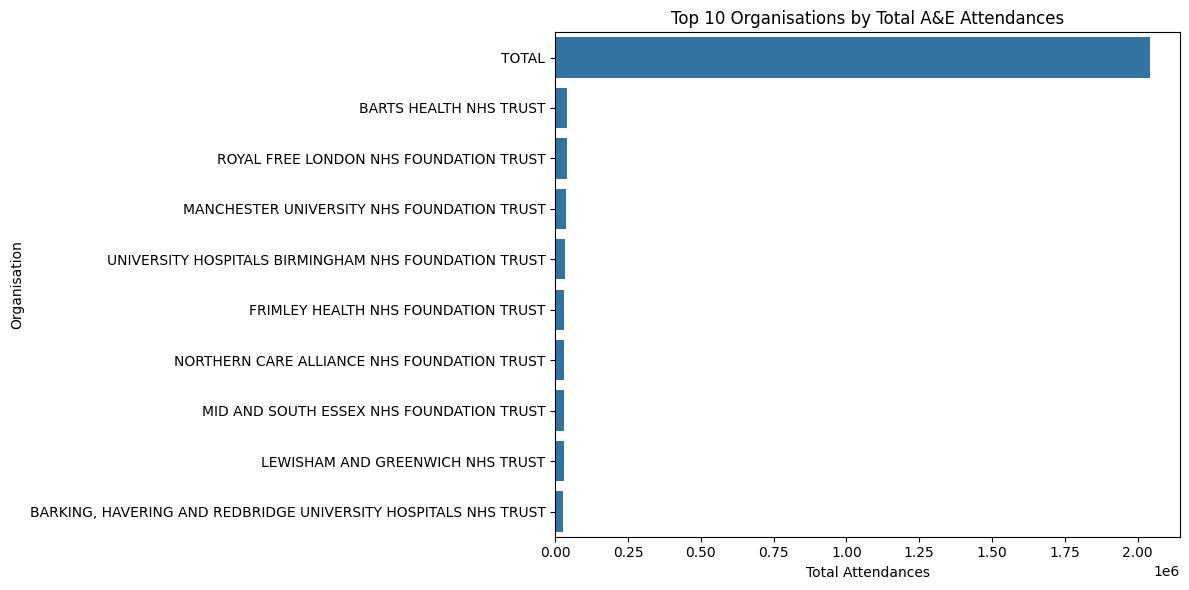

In [49]:
# Plot top 10 organisations by attendances
plt.figure(figsize=(12, 6))
sns.barplot(data=top_attendances, x="total_attendances", y="org_name")
plt.title("Top 10 Organisations by Total A&E Attendances")
plt.xlabel("Total Attendances")
plt.ylabel("Organisation")
plt.tight_layout()
plt.show()

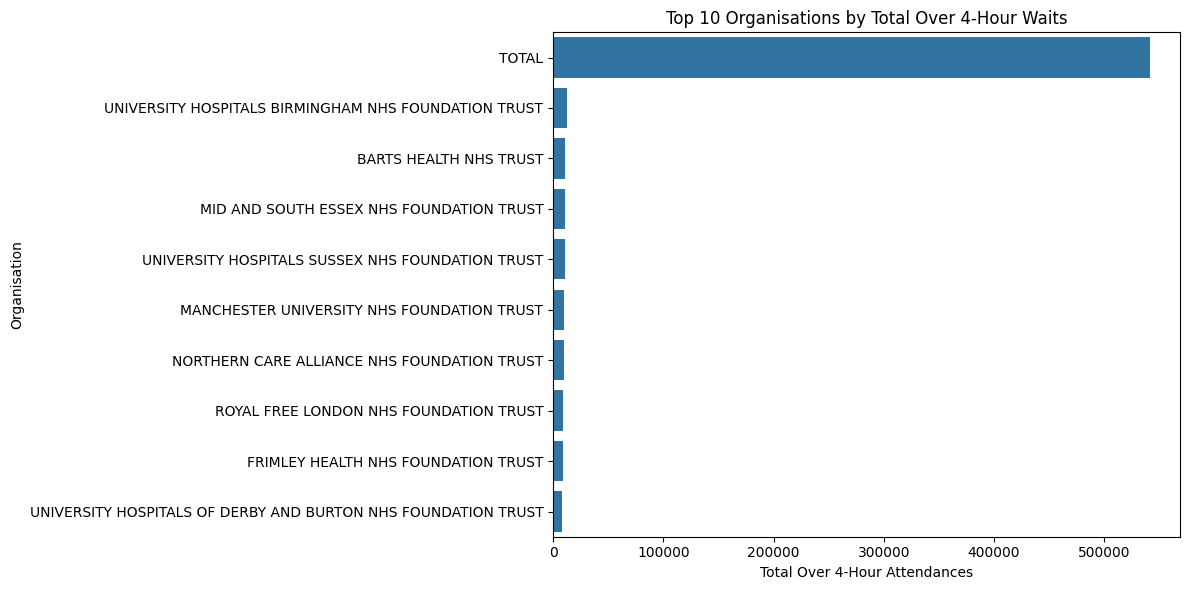

In [50]:
# Plot top 10 organisations by over 4-hour waits
plt.figure(figsize=(12, 6))
sns.barplot(data=top_over4, x="total_over_4hrs", y="org_name")
plt.title("Top 10 Organisations by Total Over 4-Hour Waits")
plt.xlabel("Total Over 4-Hour Attendances")
plt.ylabel("Organisation")
plt.tight_layout()
plt.show()

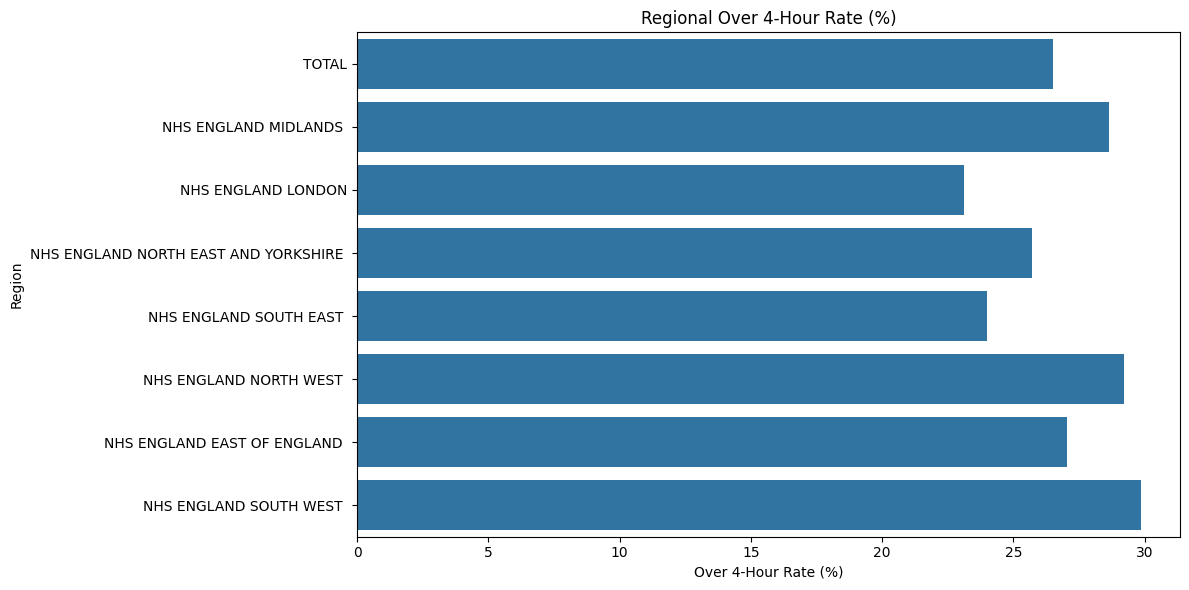

In [51]:
# Plot Regional over-4-hour rates
plt.figure(figsize=(12, 6))
sns.barplot(data=regional_summary, x="over_4hr_rate_pct", y="parent_org")
plt.title("Regional Over 4-Hour Rate (%)")
plt.xlabel("Over 4-Hour Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

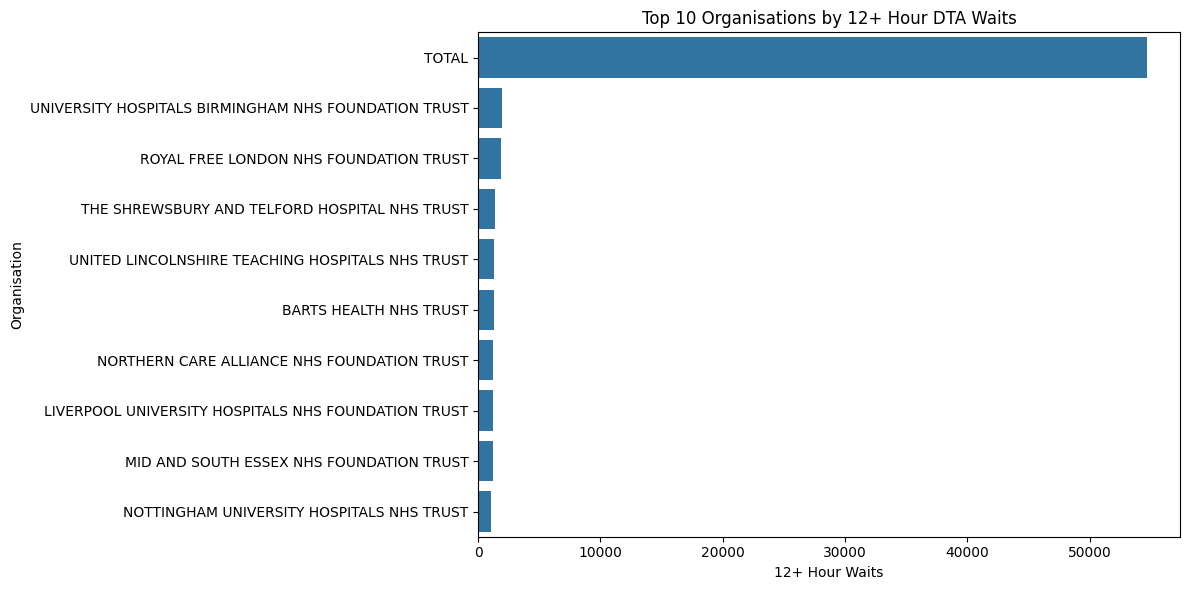

In [52]:
# top 10 by 12+ hour waits chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top_12plus, x="waits_12plus_hrs", y="org_name")
plt.title("Top 10 Organisations by 12+ Hour DTA Waits")
plt.xlabel("12+ Hour Waits")
plt.ylabel("Organisation")
plt.tight_layout()
plt.show()

## Key Insights

### 1. Demand pressure
The dataset shows strong variation in A&E demand across NHS organisations, with some trusts handling significantly larger attendance volumes than others.

### 2. Waiting time pressure
A number of organisations recorded very high volumes of attendances over 4 hours, showing operational strain and possible patient flow challenges.

### 3. Regional differences
Regional summaries indicate that A&E pressure is not evenly distributed across England.

### 4. Long waits
Some organisations reported especially high numbers of 12+ hour DTA waits, which may suggest bottlenecks in admission flow.

### 5. Admissions
Emergency admission rates also vary by organisation, indicating differences in case mix, acuity, or local service demand.

In [41]:
df.to_csv("cleaned_nhs_ae_feb_2026.csv", index=False)
print("Cleaned CSV saved successfully.")

Cleaned CSV saved successfully.


In [42]:
# Regional Summary
regional_summary.to_csv("regional_summary.csv", index=False)
print("Regional summary exported.")

Regional summary exported.


In [43]:
# Top Trusts by waits
top_over4.to_csv("top_10_over4_waits.csv", index=False)
top_12plus.to_csv("top_10_12plus_waits.csv", index=False)
print("Top wait files exported.")

Top wait files exported.


In [44]:
# Close the database connection
conn.close()